In [73]:
import torch
torch_version = torch.__version__.split('+')[0]
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-ahuoc9of'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [74]:
import torch
print(torch.__version__)

2.2.2+cpu


In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData
from torch_geometric.utils import dropout_edge, negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import time
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import pandas as pd
from collections import defaultdict

In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_add
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")

class SGL(nn.Module):

    def __init__(
            self,
            num_users,
            num_items,
            hidden_size=256,
            num_layers=3,
            edge_dropout=0.1,
            temperature=0.2,
            ssl_weight=0.1,
            reg_weight=1e-5):

        super().__init__()

        self.num_users = num_users
        self.num_items = num_items

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.temperature = temperature
        self.ssl_weight = ssl_weight
        self.reg_weight = reg_weight

        self.edge_dropout_prob = edge_dropout

        ####################################################
        # Embeddings
        ####################################################

        self.user_embeddings = nn.Embedding(
            num_users,
            hidden_size
        )

        self.item_embeddings = nn.Embedding(
            num_items,
            hidden_size
        )

        nn.init.xavier_uniform_(
            self.user_embeddings.weight
        )

        nn.init.xavier_uniform_(
            self.item_embeddings.weight
        )

    ########################################################
    # Standard Edge Dropout
    ########################################################

    def edge_dropout(
            self,
            edge_index,
            p=None):

        if p is None:
            p = self.edge_dropout_prob

        if (not self.training) or p == 0:
            return edge_index

        mask = (
            torch.rand(
                edge_index.size(1),
                device=edge_index.device
            ) > p
        )

        return edge_index[:, mask]

    ########################################################
    # Generate Two Views
    ########################################################

    def generate_views(
            self,
            edge_index):

        view1 = self.edge_dropout(
            edge_index
        )

        view2 = self.edge_dropout(
            edge_index
        )

        return view1, view2

    ########################################################
    # LightGCN Propagation
    ########################################################

    def propagate(
            self,
            user_emb,
            item_emb,
            edge_index):

        x = torch.cat(
            [user_emb, item_emb],
            dim=0
        )

        embeddings = [x]

        src = edge_index[0]
        dst = edge_index[1] + self.num_users
        
        edge_index = torch.cat([
            torch.stack([src, dst], dim=0),
            torch.stack([dst, src], dim=0)
        ], dim=1)

        src = edge_index[0]
        dst = edge_index[1]
        
        num_nodes = x.size(0)
        
        edge_weight = torch.ones(
            edge_index.size(1),
            device=edge_index.device
        )

           
        deg = scatter_add(
             edge_weight,
             src,
             dim=0,
             dim_size=num_nodes
        )

        deg = deg.clamp(min=1)

        for _ in range(self.num_layers):

            norm = (
                deg[src].pow(-0.5)
                *
                deg[dst].pow(-0.5)
            )

            x = scatter_add(
                x[src] * norm.unsqueeze(-1),
                dst,
                dim=0,
                dim_size=num_nodes
            )

            embeddings.append(x)

        final_embedding = (
            torch.stack(
                embeddings,
                dim=0
            ).mean(dim=0)
        )

        user_embedding = (
            final_embedding[
                :self.num_users
            ]
        )

        item_embedding = (
            final_embedding[
                self.num_users:
            ]
        )

        return (
            user_embedding,
            item_embedding
        )

    ########################################################
    # Forward
    ########################################################

    def forward(
            self,
            edge_index,
            return_views=False):

        user_emb = (
            self.user_embeddings.weight
        )

        item_emb = (
            self.item_embeddings.weight
        )

        if self.training and return_views:

            view1, view2 = (
                self.generate_views(
                    edge_index
                )
            )

            emb1 = self.propagate(
                user_emb,
                item_emb,
                view1
            )

            emb2 = self.propagate(
                user_emb,
                item_emb,
                view2
            )

            return emb1, emb2

        return self.propagate(
            user_emb,
            item_emb,
            edge_index
        )

    ########################################################
    # Prediction
    ########################################################

    def predict(
            self,
            user_emb,
            item_emb,
            user_ids,
            item_ids):

        u = user_emb[user_ids]

        i = item_emb[item_ids]

        return torch.sum(
            u * i,
            dim=-1
        )

    ########################################################
    # InfoNCE Loss
    ########################################################

    def contrastive_loss(self,user_emb1,user_emb2):

        z1 = F.normalize(user_emb1,dim=1)

        z2 = F.normalize(user_emb2,dim=1)

       
        logits_12 = torch.mm(z1, z2.t()) / self.temperature
        logits_21 = torch.mm(z2, z1.t()) / self.temperature 
                
        labels = torch.arange(z1.size(0),device=z1.device)

        loss1 = F.cross_entropy(logits_12,labels)

        loss2 = F.cross_entropy(logits_21,labels)

        ssl_loss = (loss1 + loss2) / 2
        

        return ssl_loss

    ########################################################
    # BPR Loss
    ########################################################

    def bpr_loss(
            self,
            user_emb,
            item_emb,
            pos_edge_index,
            neg_edge_index):

        pos_scores = self.predict(
            user_emb,
            item_emb,
            pos_edge_index[0],
            pos_edge_index[1]
        )

        neg_scores = self.predict(
            user_emb,
            item_emb,
            neg_edge_index[0],
            neg_edge_index[1]
        )

        bpr = -torch.log(
            torch.sigmoid(
                pos_scores -
                neg_scores
            ) + 1e-12
        ).mean()

        reg_loss = (
            self.user_embeddings.weight
            .norm(2).pow(2)
            +
            self.item_embeddings.weight
            .norm(2).pow(2)
        )

        reg_loss = (
            self.reg_weight *
            reg_loss
        )

        return bpr + reg_loss

    ########################################################
    # Total Loss
    ########################################################

    def total_loss(
            self,
            pos_edge_index,
            neg_edge_index,
            edge_index):
        
        main_user_emb, main_item_emb = self.forward(
            edge_index,
            return_views=False
        )
        
        (
            (user_emb1, item_emb1),
            (user_emb2, item_emb2)
        ) = self.forward(
            edge_index,
            return_views=True
        )

        bpr = self.bpr_loss(
            main_user_emb,
            main_item_emb,
            pos_edge_index,
            neg_edge_index
        )

        user_ssl = self.contrastive_loss(
            user_emb1,
            user_emb2
        )

        item_ssl = self.contrastive_loss(
            item_emb1,
            item_emb2
        )

        ssl = (user_ssl + item_ssl) / 2

        total = (
            bpr +
            self.ssl_weight * ssl
        )

        return total, bpr, ssl

Random seed set to 42


In [77]:
def prepare_sgl_data(data, val_ratio=0.1, test_ratio=0.1):
    """Prepare data for SGL training"""
    edge_index = data['user', 'listens', 'artist'].edge_index
    
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)
    
    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test
    
    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]
    
    train_pos_edge_index = edge_index[:, train_idx]
    val_pos_edge_index = edge_index[:, val_idx]
    test_pos_edge_index = edge_index[:, test_idx]

    data.train_pos_edge_index = train_pos_edge_index
    data.val_pos_edge_index = val_pos_edge_index
    data.test_pos_edge_index = test_pos_edge_index
    
    num_users = data['user'].num_nodes
    num_items = data['artist'].num_nodes
    
    positive_set = set(
    map(tuple, train_pos_edge_index.t().cpu().numpy())
    )
    
    def sample_negatives(num_samples):

        neg_edges = []
        used_negatives = set()

        while len(neg_edges) < num_samples:

            user = torch.randint(
                0,
                num_users,
                (1,)
            ).item()

            artist = torch.randint(
            0,
            num_items,
            (1,)
            ).item()

            if (
                (user, artist) not in positive_set
                and
                (user, artist) not in used_negatives
            ):
                neg_edges.append(
                    [user, artist]
                )

                used_negatives.add(
                    (user, artist)
                )    
                
        return torch.tensor(
            neg_edges,
            dtype=torch.long
        ).t()
    
    train_neg = sample_negatives(train_pos_edge_index.size(1))
    val_neg = sample_negatives(val_pos_edge_index.size(1))
    test_neg = sample_negatives(test_pos_edge_index.size(1))
    
    data.train_pos_edge_index = train_pos_edge_index
    data.train_neg_edge_index = train_neg
    data.val_edge_index = torch.cat([val_pos_edge_index, val_neg], dim=1)
    data.val_edge_label = torch.cat([torch.ones(val_pos_edge_index.size(1)), torch.zeros(val_neg.size(1))])
    data.test_edge_index = torch.cat([test_pos_edge_index, test_neg], dim=1)
    data.test_edge_label = torch.cat([torch.ones(test_pos_edge_index.size(1)), torch.zeros(test_neg.size(1))])
    
    return data


def train_sgl_with_data_sgl(data, config):
    """Train SGL model on LastFm data"""
    device = config.get('device', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    
    data = prepare_sgl_data(data)
    
    data.train_pos_edge_index = data.train_pos_edge_index.to(device)
    data.train_neg_edge_index = data.train_neg_edge_index.to(device)

    data.val_pos_edge_index = data.val_pos_edge_index.to(device)
    data.test_pos_edge_index = data.test_pos_edge_index.to(device)

    data.val_edge_index = data.val_edge_index.to(device)
    data.val_edge_label = data.val_edge_label.to(device)

    data.test_edge_index = data.test_edge_index.to(device)
    data.test_edge_label = data.test_edge_label.to(device)
    
    model = SGL(
        num_users=data['user'].num_nodes,
        num_items=data['artist'].num_nodes,
        hidden_size=config.get('hidden_size', 256),
        num_layers=config.get('num_layers', 3),
        edge_dropout=config.get('edge_dropout', 0.1),
        temperature=config.get('temperature', 0.2),
        ssl_weight=config.get('ssl_weight', 0.1),
        reg_weight=config.get('reg_weight', 1e-5)
    ).to(device)
    
    # Create optimizer and trainer function
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get('learning_rate', 5e-4),
        weight_decay=config.get('weight_decay', 0)
    )
    
    num_epochs = config.get('epochs', 200)
    
    losses = []
    val_aucs = []
    
    print("Training SGL Model...")
    for epoch in trange(num_epochs, desc="SGL Training"):
        model.train()
        optimizer.zero_grad()
        
        # Generate fresh negatives every epoch - FIX: use tuple for num_nodes
        train_neg_edge_index = negative_sampling(
            edge_index=data.train_pos_edge_index,
            num_nodes=(data['user'].num_nodes, data['artist'].num_nodes),
            num_neg_samples=data.train_pos_edge_index.size(1)
        ).to(data.train_pos_edge_index.device)

        # Calculate losses
        total_loss, bpr_loss, ssl_loss = model.total_loss(
            data.train_pos_edge_index,
            train_neg_edge_index,
            data.train_pos_edge_index
        )
        
        total_loss.backward()
        optimizer.step()
        
        losses.append({
            'total_loss': total_loss.item(),
            'bpr_loss': bpr_loss.item() if isinstance(bpr_loss, torch.Tensor) else bpr_loss,
            'ssl_loss': ssl_loss.item() if isinstance(ssl_loss, torch.Tensor) else ssl_loss
        })
        
        if epoch % 5 == 0:
            # print(
            #   f"Epoch {epoch} | "
            #   f"Total={total_loss.item():.4f} | "
            #   f"BPR={bpr_loss.item():.4f} | "
            #   f"SSL={ssl_loss.item():.4f}"
            #)
            model.eval()
            with torch.no_grad():
                user_emb, item_emb = model(data.train_pos_edge_index)
                
                # Validation prediction
                val_pred = model.predict(
                    user_emb,
                    item_emb,
                    data.val_edge_index[0],
                    data.val_edge_index[1]
                )
                val_pred = torch.sigmoid(val_pred)
                
                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )
                val_aucs.append(val_auc)
                
                
        
    model.eval()
    with torch.no_grad():
        # Test prediction
        user_emb, item_emb = model(data.train_pos_edge_index)
        
        test_pred = model.predict(
            user_emb,
            item_emb,
            data.test_edge_index[0],
            data.test_edge_index[1]
        )
        test_pred = torch.sigmoid(test_pred)
        
        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )
        
        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )
        
        test_metrics = {'AUC': test_auc, 'AP': test_ap}
        
        # Calculate recommendation metrics
        rec_metrics = evaluate_recommendation_metrics_sgl(
            model,
            data,
            k_list=[5, 10, 20]
        )
        print("\nDEBUG RECOMMENDATION")

        print(
            "Train Pos:",
            data.train_pos_edge_index.shape
        )

        print(
            "Test Pos:",
            data.test_pos_edge_index.shape
        )

        print(
            "Unique Test Users:",
            len(
            torch.unique(
            data.test_pos_edge_index[0]
            )
           )
        )

        print(
            "Unique Test Artists:",
            len(
            torch.unique(
                data.test_pos_edge_index[1]
             )
          )
        )
        
    return {
        'model': model,
        'losses': losses,
        'val_aucs': val_aucs,
        'test_metrics': test_metrics,
        'rec_metrics': rec_metrics
        
    }

## Training and Testing

In [78]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
import numpy as np

def download_and_extract_lastfm():
    """Download LastFM HetRec 2011 dataset and extract it"""

    print("Downloading LastFM HetRec 2011 dataset...")

    url = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"

    response = requests.get(
        url,
        timeout=120
    )

    if response.status_code != 200:
        raise Exception(
            f"Failed to download dataset: HTTP {response.status_code}"
        )

    extract_path = "lastfm"

    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    with zipfile.ZipFile(
        io.BytesIO(response.content)
    ) as zip_ref:

        zip_ref.extractall(
            extract_path
        )

    print(
        "Dataset downloaded and extracted successfully!"
    )

    extracted_folder = os.path.join(
        extract_path,
        "hetrec2011-lastfm-2k"
    )

    if os.path.exists(extracted_folder):

        print(
            f"Files extracted to: {extracted_folder}"
        )

        return extracted_folder

    return extract_path

def encode_user_features(num_users):
    """
    Create user features for LastFM users

    LastFM does not provide demographic
    information such as age, gender or
    occupation. Therefore a simple constant
    feature vector is used.
    """

    user_features = torch.ones(
        (num_users, 1),
        dtype=torch.float
    )

    print("User feature information:")
    print(f"  Number of users: {num_users}")
    print(f"  User feature dimension: {user_features.shape[1]}")

    return user_features

def encode_artist_features(num_artists):
    """
    Create artist features for LastFM

    The LastFM HetRec dataset does not provide
    genre/category features for artists.
    Therefore, we use a simple feature vector
    of ones for each artist.
    """

    artist_features = torch.ones(
        (num_artists, 1),
        dtype=torch.float
    )

    print("Artist feature information:")
    print(f"  Number of artists: {num_artists}")
    print(f"  Artist feature dimension: {artist_features.shape[1]}")

    return artist_features

def load_lastfm_heterogeneous(data_path, use_features=True):
    """Load LastFM HetRec 2011 dataset"""

    print(f"Loading LastFM dataset from: {data_path}")

    print("\nAvailable files in directory:")
    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except Exception:
        print("  Could not list directory contents")

    # ==================================================
    # Load files
    # ==================================================

    try:
        user_artists_df = pd.read_csv(
            os.path.join(data_path, "user_artists.dat"),
            sep="\t"
        )

        print(
            f"✓ Loaded user_artists.dat: "
            f"{len(user_artists_df)} records"
        )

    except Exception as e:
        print(f"✗ user_artists.dat error: {e}")
        raise

    try:
        artists_df = pd.read_csv(
            os.path.join(data_path, "artists.dat"),
            sep="\t",
            encoding="latin-1"
        )

        print(
            f"✓ Loaded artists.dat: "
            f"{len(artists_df)} records"
        )

    except Exception as e:
        print(f"✗ artists.dat error: {e}")
        raise

    # ==================================================
    # Create HeteroData
    # ==================================================

    data = HeteroData()

    all_users = sorted(
        user_artists_df["userID"].unique()
    )

    all_artists = sorted(
        user_artists_df["artistID"].unique()
    )

    num_users = len(all_users)
    num_artists = len(all_artists)

    user_id_to_idx = {
        uid: idx
        for idx, uid in enumerate(all_users)
    }

    artist_id_to_idx = {
        aid: idx
        for idx, aid in enumerate(all_artists)
    }

    print(
        f"\nStatistics - Users: {num_users}, "
        f"Artists: {num_artists}"
    )

    # ==================================================
    # Features
    # ==================================================

    if use_features:

        user_features = encode_user_features(
            num_users
        )

        artist_features = encode_artist_features(
            num_artists
        )

    else:

        user_features = torch.ones(
            (num_users, 1),
            dtype=torch.float
        )

        artist_features = torch.ones(
            (num_artists, 1),
            dtype=torch.float
        )

    user_feat_dim = user_features.shape[1]
    artist_feat_dim = artist_features.shape[1]

    print("\nFeature dimensions:")
    print(f"  User features: {user_feat_dim}")
    print(f"  Artist features: {artist_feat_dim}")

    data["user"].x = user_features
    data["artist"].x = artist_features

    # ==================================================
    # Node counts
    # ==================================================

    data["user"].num_nodes = num_users
    data["artist"].num_nodes = num_artists

    # ==================================================
    # User → Artist edges
    # ==================================================

    user_idx = user_artists_df["userID"].map(
        user_id_to_idx
    ).values

    artist_idx = user_artists_df["artistID"].map(
        artist_id_to_idx
    ).values

    edge_index = torch.tensor(
        np.vstack(
            [user_idx, artist_idx]
        ),
        dtype=torch.long
    )

    edge_weight = torch.tensor(
        user_artists_df["weight"].values,
        dtype=torch.float
    )

    valid_edges = edge_index.size(1)

    print(
        f"User-listens-artist relations: "
        f"{valid_edges}"
    )

    data[
        "user",
        "listens",
        "artist"
    ].edge_index = edge_index

    data[
        "user",
        "listens",
        "artist"
    ].weight = edge_weight

    data[
        "artist",
        "rev_listens",
        "user"
    ].edge_index = edge_index.flip(0)

    data[
        "artist",
        "rev_listens",
        "user"
    ].weight = edge_weight

    data[
        "user",
        "listens",
        "artist"
    ].original_edge_index = edge_index.clone()

    print("\nFINAL STATISTICS:")
    print(f"  Users: {data['user'].num_nodes}")
    print(f"  Artists: {data['artist'].num_nodes}")
    print(f"  User→Artist edges: {valid_edges}")
    print(f"  User feature dimension: {user_feat_dim}")
    print(f"  Artist feature dimension: {artist_feat_dim}")

    return (
        data,
        user_feat_dim,
        artist_feat_dim
    )


def train_link_prediction_model(data, model, configuration):
    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configuration.epochs,
        eta_min=1e-6
    )

    losses = []
    val_aucs = []

    best_val_auc = 0.0
    best_model_state = None

    num_epochs = configuration.epochs

    for epoch in trange(num_epochs):

        model.train()
        optimizer.zero_grad()

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        artist_emb = z['artist']

        pos_edge_index = data.train_pos_edge_index
        num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=data.train_pos_edge_index,
            num_nodes=(
            data['user'].num_nodes,
            data['artist'].num_nodes
        ),
        num_neg_samples=num_pos
        )

        pos_pred = model.decode(
            user_emb,
            artist_emb,
            pos_edge_index
        )

        neg_pred = model.decode(
            user_emb,
            artist_emb,
            neg_edge_index
        )

        pos_loss = -torch.log(
            torch.sigmoid(pos_pred) + 1e-15
        ).mean()

        neg_loss = -torch.log(
            1 - torch.sigmoid(neg_pred) + 1e-15
        ).mean()

        loss = pos_loss + neg_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if epoch % 5 == 0:

            model.eval()

            with torch.no_grad():

                z, importance = model(
                    node_features,
                    edge_indices,
                    edge_timestamps
                )

                user_emb = z['user']
                artist_emb = z['artist']

                val_pred = model.decode(
                    user_emb,
                    artist_emb,
                    data.val_edge_index
                )

                val_pred = torch.sigmoid(val_pred)

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )

                val_aucs.append(val_auc)

                if val_auc > best_val_auc:

                    best_val_auc = val_auc

                    best_model_state = {
                        k: v.cpu().clone()
                        for k, v in model.state_dict().items()
                    }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()

    with torch.no_grad():

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        artist_emb = z['artist']

        test_pred = model.decode(
            user_emb,
            artist_emb,
            data.test_edge_index
        )

        test_pred = torch.sigmoid(test_pred)

        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

    test_metrics = {
        'auc': test_auc,
        'ap': test_ap
    }

    return (
        val_aucs,
        losses,
        model,
        test_metrics
    )


def evaluate_recommendation_metrics_sgl(
    model,
    data,
    k_list=[5, 10, 20]
):
    model.eval()

    with torch.no_grad():
        user_emb, item_emb = model(
            data.train_pos_edge_index
        )

    # =========================
    # Use TEST interactions
    # =========================
    test_edges = data.test_pos_edge_index.cpu()

    print("Test Edge Shape:", test_edges.shape)

    if test_edges.size(1) == 0:
        print("ERROR: No test interactions found!")
        return {
            'HR@5': 0.0,
            'HR@10': 0.0,
            'HR@20': 0.0,
            'NDCG@5': 0.0,
            'NDCG@10': 0.0,
            'NDCG@20': 0.0,
            'MRR': 0.0
        }

    num_users = data['user'].num_nodes

    print(
        "Unique Test Users:",
        len(set(test_edges[0].numpy()))
    )

    print(
        "Unique Test Artists:",
        len(set(test_edges[1].numpy()))
    )

    # =========================
    # Ground Truth Test Items
    # =========================
    test_user_items = {}

    for u, i in test_edges.t().numpy():
        test_user_items.setdefault(
            int(u),
            set()
        ).add(
            int(i)
        )

    # =========================
    # Training Items
    # =========================
    train_user_items = {}

    train_edges = data.train_pos_edge_index.cpu()

    for u, i in train_edges.t().numpy():
        train_user_items.setdefault(
            int(u),
            set()
        ).add(
            int(i)
        )

    results = {}

    for k in k_list:
        results[f'HR@{k}'] = []
        results[f'NDCG@{k}'] = []

    mrr_scores = []

    # =========================
    # Evaluate per user
    # =========================
    for user in test_user_items.keys():

        gt_items = list(
            test_user_items[user]
        )

        scores = torch.matmul(
            user_emb[user],
            item_emb.T
        ).cpu()

        # Remove training items
        if user in train_user_items:

            train_items = list(
                train_user_items[user]
            )

            scores[
                train_items
            ] = -1e9

        _, ranking = torch.sort(
            scores,
            descending=True
        )

        ranking = ranking.numpy()

        rank_positions = []

        for item in gt_items:

            pos = np.where(
                ranking == item
            )[0]

            if len(pos) > 0:
                rank_positions.append(
                    pos[0] + 1
                )

        if len(rank_positions) == 0:
            continue

        best_rank = min(
            rank_positions
        )

        mrr_scores.append(
            1.0 / best_rank
        )

        for k in k_list:

            hits = [
                r
                for r in rank_positions
                if r <= k
            ]

            hr = (
                1.0
                if len(hits) > 0
                else 0.0
            )

            if len(hits) > 0:

                ndcg = max(
                    1.0 / np.log2(r + 1)
                    for r in hits
                )

            else:

                ndcg = 0.0

            results[
                f'HR@{k}'
            ].append(hr)

            results[
                f'NDCG@{k}'
            ].append(ndcg)

    final_results = {}

    for k in k_list:

        if len(
            results[f'HR@{k}']
        ) > 0:

            final_results[
                f'HR@{k}'
            ] = float(
                np.mean(
                    results[f'HR@{k}']
                )
            )

            final_results[
                f'NDCG@{k}'
            ] = float(
                np.mean(
                    results[f'NDCG@{k}']
                )
            )

        else:

            final_results[
                f'HR@{k}'
            ] = 0.0

            final_results[
                f'NDCG@{k}'
            ] = 0.0

    final_results['MRR'] = (
        float(np.mean(mrr_scores))
        if len(mrr_scores) > 0
        else 0.0
    )

    return final_results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)

In [79]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(
    data,
    val_ratio=0.1,
    test_ratio=0.1
):

    edge_index = data[
        'user',
        'listens',
        'artist'
    ].edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test

    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]

    # ==================================================
    # Positive edges
    # ==================================================

    train_pos_edge_index = edge_index[:, train_idx]

    val_pos_edge_index = edge_index[:, val_idx]

    test_pos_edge_index = edge_index[:, test_idx]

    # ==================================================
    # Use only TRAIN graph as known graph
    # ==================================================

    known_edges = torch.cat(
        [
            train_pos_edge_index,
            val_pos_edge_index,
            test_pos_edge_index
        ],
        dim=1
    )

    # ==================================================
    # Negative sampling
    # ==================================================

    train_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['artist'].num_nodes
        ),
        num_neg_samples=train_pos_edge_index.size(1)
    )

    val_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['artist'].num_nodes
        ),
        num_neg_samples=val_pos_edge_index.size(1)
    )

    test_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['artist'].num_nodes
        ),
        num_neg_samples=test_pos_edge_index.size(1)
    )

    # ==================================================
    # Store train edges
    # ==================================================

    data.train_pos_edge_index = train_pos_edge_index
    data.train_neg_edge_index = train_neg_edge_index

    data.val_pos_edge_index = val_pos_edge_index
    data.val_neg_edge_index = val_neg_edge_index

    data.test_pos_edge_index = test_pos_edge_index
    data.test_neg_edge_index = test_neg_edge_index

    # ==================================================
    # Train set
    # ==================================================

    data.train_edge_index = torch.cat(
        [
            train_pos_edge_index,
            train_neg_edge_index
        ],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(
                train_pos_edge_index.size(1)
            ),
            torch.zeros(
                train_neg_edge_index.size(1)
            )
        ]
    )

    # ==================================================
    # Validation set
    # ==================================================

    data.val_edge_index = torch.cat(
        [
            val_pos_edge_index,
            val_neg_edge_index
        ],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(
                val_pos_edge_index.size(1)
            ),
            torch.zeros(
                val_neg_edge_index.size(1)
            )
        ]
    )

    # ==================================================
    # Test set
    # ==================================================

    data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(
                test_pos_edge_index.size(1)
            ),
            torch.zeros(
                test_neg_edge_index.size(1)
            )
        ]
    )

    print("\nLink Prediction Split:")
    print(
        f"Train Pos Edges : "
        f"{train_pos_edge_index.size(1)}"
    )

    print(
        f"Val Pos Edges   : "
        f"{val_pos_edge_index.size(1)}"
    )

    print(
        f"Test Pos Edges  : "
        f"{test_pos_edge_index.size(1)}"
    )

    print(
        f"Train Neg Edges : "
        f"{train_neg_edge_index.size(1)}"
    )

    print(
        f"Val Neg Edges   : "
        f"{val_neg_edge_index.size(1)}"
    )

    print(
        f"Test Neg Edges  : "
        f"{test_neg_edge_index.size(1)}"
    )

    return data

Using device: cpu

STEP 1: Loading LastFm Dataset
Dataset downloaded and extracted successfully!
Loading LastFM dataset from: lastfm

Available files in directory:
  - artists.dat
  - readme.txt
  - tags.dat
  - user_artists.dat
  - user_friends.dat
  - user_taggedartists-timestamps.dat
  - user_taggedartists.dat
✓ Loaded user_artists.dat: 92834 records
✓ Loaded artists.dat: 17632 records

Statistics - Users: 1892, Artists: 17632
User feature information:
  Number of users: 1892
  User feature dimension: 1
Artist feature information:
  Number of artists: 17632
  Artist feature dimension: 1

Feature dimensions:
  User features: 1
  Artist features: 1
User-listens-artist relations: 92834

FINAL STATISTICS:
  Users: 1892
  Artists: 17632
  User→Artist edges: 92834
  User feature dimension: 1
  Artist feature dimension: 1

STEP 2: Training SGL Model
Training SGL Model...


SGL Training: 100%|██████████████████████████████████████████████████████████████████| 200/200 [09:58<00:00,  2.99s/it]


Test Edge Shape: torch.Size([2, 9283])
Unique Test Users: 1858
Unique Test Artists: 4027

DEBUG RECOMMENDATION
Train Pos: torch.Size([2, 74268])
Test Pos: torch.Size([2, 9283])
Unique Test Users: 1858
Unique Test Artists: 4027

FINAL RESULTS - SGL
Model: SGL
Dataset: LastFM (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC: 0.7516
AP: 0.7634

--- RECOMMENDATION METRICS ---
HR@5: 0.1448
HR@10: 0.2277
HR@20: 0.3213
NDCG@5: 0.0999
NDCG@10: 0.1266
NDCG@20: 0.1501
MRR: 0.1091
Time Taken: 604.19 seconds


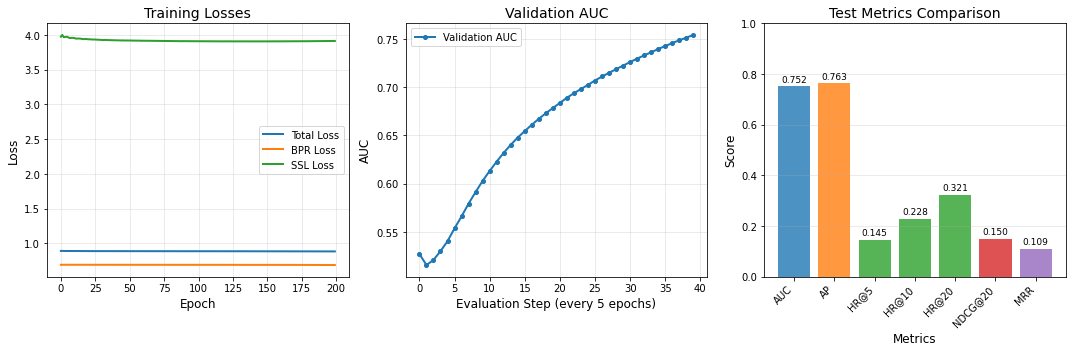

In [80]:
def main_sgl():
    """Main function to run SGL on Lastfm dataset"""
    
    config = {
        'model_type': 'SGL',
        'dataset': 'LastFM',
        'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),

        'hidden_size': 64,
        'num_layers': 3,

        'edge_dropout': 0.1,
        'temperature': 0.2,
        'ssl_weight': 0.05,
        'weight_decay': 1e-6,
        
        'reg_weight': 1e-6,

        'learning_rate': 1e-3,
        'epochs': 200
        
    }
    
            
    print(f"Using device: {config['device']}")
    
    print("\n" + "=" * 60)
    print("STEP 1: Loading LastFm Dataset")
    print("=" * 60)
    
    data_path = download_and_extract_lastfm()
    heterogeneous_data, user_feat_dim, artist_feat_dim = load_lastfm_heterogeneous(
        data_path,
        use_features=True
        
    )
    
    
    heterogeneous_data = heterogeneous_data.to(config['device'])
    
    print("\n" + "=" * 60)
    print("STEP 2: Training SGL Model")
    print("=" * 60)
    
    start_time = time.time()
    # FIX: Use the correct function name
    results = train_sgl_with_data_sgl(heterogeneous_data, config)
    end_time = time.time()
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS - SGL")
    print("=" * 60)
    print(f"Model: {config['model_type']}")
    print(f"Dataset: {config['dataset']} (Link Prediction)")
    
    print("\n--- LINK PREDICTION METRICS ---")
    print(f"AUC: {results['test_metrics']['AUC']:.4f}")
    print(f"AP: {results['test_metrics']['AP']:.4f}")
    
    
    print("\n--- RECOMMENDATION METRICS ---")
    # Hit Ratio metrics
    print(f"HR@5: {results['rec_metrics']['HR@5']:.4f}")
    print(f"HR@10: {results['rec_metrics']['HR@10']:.4f}")
    print(f"HR@20: {results['rec_metrics']['HR@20']:.4f}")
    
    

    # NDCG metrics
    print(f"NDCG@5: {results['rec_metrics']['NDCG@5']:.4f}")
    print(f"NDCG@10: {results['rec_metrics']['NDCG@10']:.4f}")
    print(f"NDCG@20: {results['rec_metrics']['NDCG@20']:.4f}")
    
    print(f"MRR: {results['rec_metrics']['MRR']:.4f}")
    
    print(f"Time Taken: {end_time - start_time:.2f} seconds")
    
    
    
    # Create visualization
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: Training Losses
    plt.subplot(1, 3, 1)
    losses_array = [l['total_loss'] for l in results['losses']]
    plt.plot(losses_array, label='Total Loss', linewidth=2)
    plt.plot([l['bpr_loss'] for l in results['losses']], label='BPR Loss', linewidth=2)
    plt.plot([l['ssl_loss'] for l in results['losses']], label='SSL Loss', linewidth=2)
    plt.title('Training Losses', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Validation AUC over time
    plt.subplot(1, 3, 2)
    plt.plot(results['val_aucs'], marker='o', label='Validation AUC', linewidth=2, markersize=4)
    plt.title('Validation AUC', fontsize=14)
    plt.xlabel('Evaluation Step (every 5 epochs)', fontsize=12)
    plt.ylabel('AUC', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Test Metrics Comparison
    plt.subplot(1, 3, 3)
    metrics = ['AUC', 'AP', 'HR@5', 'HR@10', 'HR@20','NDCG@20','MRR']
    values = [
        results['test_metrics']['AUC'],
        results['test_metrics']['AP'],
        results['rec_metrics']['HR@5'],
        results['rec_metrics']['HR@10'],
        results['rec_metrics']['HR@20'],
        results['rec_metrics']['NDCG@20'],
        results['rec_metrics']['MRR']
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#2ca02c', '#2ca02c', '#d62728', '#9467bd']
    bars = plt.bar(metrics, values, color=colors, alpha=0.8)
    plt.title('Test Metrics Comparison', fontsize=14)
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on top of bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return results

if __name__ == '__main__':
    results = main_sgl()